In [4]:
import pandas as pd 
import numpy as np

In [20]:
file_path = r'C:\Users\nct\superstore_dataset.xlsx'

In [30]:
customers = pd.read_excel(file_path, sheet_name='customers')
products = pd.read_excel(file_path, sheet_name='products')
orders = pd.read_excel(file_path, sheet_name='orders')
sales = pd.read_excel(file_path, sheet_name='sales')

In [40]:
products.head()

,product_id,product_name,category,sub_category
0,P0001,Product 1,Technology,Accessories
1,P0002,Product 2,Technology,Copiers
2,P0003,Product 3,Office Supplies,Paper
3,P0004,Product 4,Office Supplies,NaN
4,P0005,Product 5,Technology,Machines


In [36]:
customers.head()

,customer_id,customer_name,segment,region
0,C0001,Customer 1,Consumer,West
1,C0002,Customer 2,Corporate,South
2,C0003,Customer 3,Consumer,West
3,C0004,Customer 4,Corporate,East
4,C0005,Customer 5,Home Office,West


In [34]:
orders.head()

,order_id,order_date,customer_id,ship_mode
0,O000001,2024-11-05,C0378,Standard Class
1,O000002,2025-12-09,C0300,Standard Class
2,O000003,2025-05-09,C0714,Standard Class
3,O000004,2024-07-29,C0399,Standard Class
4,O000005,2023-12-11,C0357,Standard Class


In [38]:
sales.head()

,sales_id,order_id,product_id,sales,quantity,discount,profit
0,S000001,O000001,P0047,130.52,4.0,0.00,42.66
1,S000002,O000002,P0119,283.70,4.0,0.40,-33.67
2,S000003,O000003,P0026,10.00,4.0,0.05,2.59
3,S000004,O000004,P0112,375.17,5.0,0.15,76.86
4,S000005,O000005,P0010,768.38,3.0,0.00,273.58


In [50]:
for name, df in [('PRODUCTS', products), ('ORDERS', orders), ('SALES', sales), ('CUSTOMERS', customers)]:
    print(f"===== {name} =====")
    print(df.shape)
    df.info()
    print(df.isnull().sum())
    print("\n")

===== PRODUCTS =====
(120, 4)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   product_id    120 non-null    object
 1   product_name  120 non-null    object
 2   category      120 non-null    object
 3   sub_category  110 non-null    object
dtypes: object(4)
memory usage: 3.9+ KB
product_id       0
product_name     0
category         0
sub_category    10
dtype: int64


===== ORDERS =====
(10000, 4)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   order_id     10000 non-null  object        
 1   order_date   10000 non-null  datetime64[ns]
 2   customer_id  10000 non-null  object        
 3   ship_mode    9920 non-null   object        
dtypes: datetime64[ns](1), object(3)
memory usage: 3

In [52]:
for name, df in [('PRODUCTS', products), ('ORDERS', orders), ('SALES', sales), ('CUSTOMERS', customers)]:
    print(f"{name}: {df.duplicated().sum()} duplicate rows")

PRODUCTS: 0 duplicate rows
ORDERS: 0 duplicate rows
SALES: 200 duplicate rows
CUSTOMERS: 0 duplicate rows


In [54]:
sales[sales.duplicated(keep=False)].sort_values(by='sales_id').head(10)

,sales_id,order_id,product_id,sales,quantity,discount,profit
11,S000012,O000012,P0044,842.62,6.0,0.15,168.74
10088,S000012,O000012,P0044,842.62,6.0,0.15,168.74
36,S000037,O000037,P0119,540.36,6.0,0.00,181.61
10121,S000037,O000037,P0119,540.36,6.0,0.00,181.61
10002,S000053,O000053,P0084,503.50,1.0,0.10,82.08
52,S000053,O000053,P0084,503.50,1.0,0.10,82.08
10180,S000057,O000057,P0037,130.23,8.0,0.05,36.87
56,S000057,O000057,P0037,130.23,8.0,0.05,36.87
10062,S000066,O000066,P0062,441.47,2.0,0.00,135.60
65,S000066,O000066,P0062,441.47,2.0,0.00,135.60


In [56]:
# Remove exact duplicate rows found earlier in the sales table
sales = sales.drop_duplicates()

# Confirm it worked
print(sales.shape)
print(sales.duplicated().sum())

(10000, 7)
0


In [58]:
# View the rows where sub_category is missing
products[products['sub_category'].isnull()]

,product_id,product_name,category,sub_category
3,P0004,Product 4,Office Supplies,NaN
23,P0024,Product 24,Office Supplies,NaN
31,P0032,Product 32,Technology,NaN
60,P0061,Product 61,Furniture,NaN
61,P0062,Product 62,Furniture,NaN
74,P0075,Product 75,Office Supplies,NaN
82,P0083,Product 83,Office Supplies,NaN
85,P0086,Product 86,Office Supplies,NaN
89,P0090,Product 90,Office Supplies,NaN
94,P0095,Product 95,Furniture,NaN


In [60]:
# Fill missing sub_category values with "Unknown" since the real value can't be reliably inferred
products['sub_category'] = products['sub_category'].fillna('Unknown')

# Confirm no missing values remain
print(products['sub_category'].isnull().sum())

0


In [62]:
# View a sample of rows where ship_mode is missing
orders[orders['ship_mode'].isnull()].head(10)

,order_id,order_date,customer_id,ship_mode
69,O000070,2023-03-13,C0258,NaN
98,O000099,2025-10-18,C0298,NaN
289,O000290,2023-08-15,C0677,NaN
310,O000311,2024-04-30,C0021,NaN
343,O000344,2023-08-29,C0750,NaN
569,O000570,2023-01-09,C0500,NaN
630,O000631,2025-08-20,C0121,NaN
713,O000714,2024-08-28,C0647,NaN
718,O000719,2025-04-02,C0335,NaN
772,O000773,2024-09-03,C0301,NaN


In [66]:
# Fill missing ship_mode values with "Unknown" since shipping isn't central to this analysis
orders['ship_mode'] = orders['ship_mode'].fillna('Unknown')

# Confirm no missing values remain
print(orders['ship_mode'].isnull().sum())

0


In [68]:
# Check summary statistics for quantity and discount
sales[['quantity', 'discount']].describe()

,quantity,discount
count,9880.000000,9850.000000
mean,4.505870,0.112381
std,2.296735,0.099968
min,1.000000,0.000000
25%,3.000000,0.000000
50%,5.000000,0.100000
75%,7.000000,0.150000
max,8.000000,0.400000


In [70]:
# Fill missing quantity values with the median (robust to outliers, and quantity should be a whole number)
sales['quantity'] = sales['quantity'].fillna(sales['quantity'].median())

# Fill missing discount values with the median
sales['discount'] = sales['discount'].fillna(sales['discount'].median())

# Confirm no missing values remain
print(sales[['quantity', 'discount']].isnull().sum())

quantity    0
discount    0
dtype: int64


In [72]:
# View rows where customer_name is missing
customers[customers['customer_name'].isnull()].head(10)

,customer_id,customer_name,segment,region
8,C0009,NaN,Consumer,Central
15,C0016,NaN,Home Office,West
26,C0027,NaN,Consumer,East
53,C0054,NaN,Consumer,South
80,C0081,NaN,Consumer,West
115,C0116,NaN,Home Office,East
170,C0171,NaN,Consumer,East
187,C0188,NaN,Consumer,Central
192,C0193,NaN,Consumer,West
200,C0201,NaN,Corporate,East


In [76]:
# Fill missing customer_name values with "Unknown" since the real name can't be recovered
customers['customer_name'] = customers['customer_name'].fillna('Unknown')

# Confirm no missing values remain
print(customers['customer_name'].isnull().sum())

0


In [78]:
# Check summary statistics for sales and profit
sales[['sales', 'profit']].describe()

,sales,profit
count,10000.000000,10000.000000
mean,531.407307,88.795921
std,434.686911,104.731460
min,10.000000,-276.200000
25%,171.447500,19.277500
50%,421.220000,53.860000
75%,792.907500,136.710000
max,2592.310000,803.340000


In [82]:
# Check unique values in key categorical columns for inconsistent casing/spelling
print(products['category'].unique())
print(customers['segment'].unique())
print(customers['region'].unique())
print(orders['ship_mode'].unique())

['Technology' 'Office Supplies' 'Furniture']
['Consumer' 'Corporate' 'Home Office']
['West' 'South' 'East' 'Central']
['Standard Class' 'Second Class' 'Same Day' 'First Class' 'Unknown']


In [84]:
# Merge sales with orders (adds order_date, customer_id, ship_mode to each sale)
merged = sales.merge(orders, on='order_id', how='left')

# Merge with products (adds product_name, category, sub_category to each sale)
merged = merged.merge(products, on='product_id', how='left')

# Merge with customers (adds customer_name, segment, region to each sale)
merged = merged.merge(customers, on='customer_id', how='left')

# Check the result
print(merged.shape)
merged.head()

(10000, 16)


,sales_id,order_id,product_id,sales,quantity,discount,profit,order_date,customer_id,ship_mode,product_name,category,sub_category,customer_name,segment,region
0,S000001,O000001,P0047,130.52,4.0,0.00,42.66,2024-11-05,C0378,Standard Class,Product 47,Office Supplies,Appliances,Customer 378,Home Office,Central
1,S000002,O000002,P0119,283.70,4.0,0.40,-33.67,2025-12-09,C0300,Standard Class,Product 119,Furniture,Bookcases,Customer 300,Corporate,Central
2,S000003,O000003,P0026,10.00,4.0,0.05,2.59,2025-05-09,C0714,Standard Class,Product 26,Furniture,Chairs,Customer 714,Home Office,East
3,S000004,O000004,P0112,375.17,5.0,0.15,76.86,2024-07-29,C0399,Standard Class,Product 112,Technology,Machines,Customer 399,Consumer,Central
4,S000005,O000005,P0010,768.38,3.0,0.00,273.58,2023-12-11,C0357,Standard Class,Product 10,Technology,Machines,Customer 357,Corporate,West


In [86]:
# Check for any missing values introduced by the merge (would indicate an ID mismatch)
merged.isnull().sum()

sales_id         0
order_id         0
product_id       0
sales            0
quantity         0
discount         0
profit           0
order_date       0
customer_id      0
ship_mode        0
product_name     0
category         0
sub_category     0
customer_name    0
segment          0
region           0
dtype: int64

In [88]:
# Save the cleaned, merged dataset to a new CSV for use in analysis
merged.to_csv('superstore_cleaned.csv', index=False)

In [90]:
# Export each cleaned table separately so they can be loaded into SQL and joined there
products.to_csv('products_clean.csv', index=False)
orders.to_csv('orders_clean.csv', index=False)
sales.to_csv('sales_clean.csv', index=False)
customers.to_csv('customers_clean.csv', index=False)

In [92]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a clean visual style for all charts
sns.set_style('whitegrid')

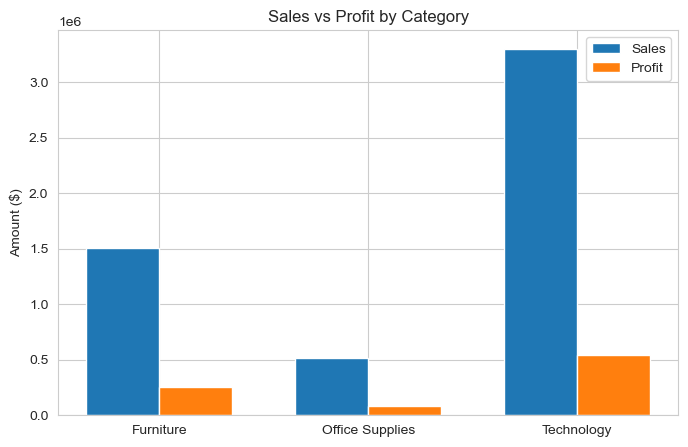

In [94]:
# Group data by category to get total sales and profit per category
category_summary = merged.groupby('category')[['sales', 'profit']].sum().reset_index()

# Create side-by-side bar chart comparing sales and profit across categories
fig, ax = plt.subplots(figsize=(8, 5))
x = range(len(category_summary))
width = 0.35

ax.bar([i - width/2 for i in x], category_summary['sales'], width, label='Sales')
ax.bar([i + width/2 for i in x], category_summary['profit'], width, label='Profit')

ax.set_xticks(x)
ax.set_xticklabels(category_summary['category'])
ax.set_ylabel('Amount ($)')
ax.set_title('Sales vs Profit by Category')
ax.legend()

plt.show()

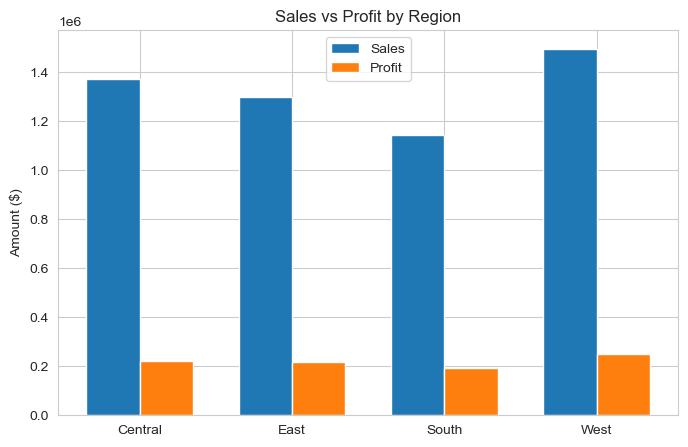

In [96]:
# Group data by region to get total sales and profit per region
region_summary = merged.groupby('region')[['sales', 'profit']].sum().reset_index()

# Create side-by-side bar chart comparing sales and profit across regions
fig, ax = plt.subplots(figsize=(8, 5))
x = range(len(region_summary))
width = 0.35

ax.bar([i - width/2 for i in x], region_summary['sales'], width, label='Sales')
ax.bar([i + width/2 for i in x], region_summary['profit'], width, label='Profit')

ax.set_xticks(x)
ax.set_xticklabels(region_summary['region'])
ax.set_ylabel('Amount ($)')
ax.set_title('Sales vs Profit by Region')
ax.legend()

plt.show()

C:\Users\nct\AppData\Local\Temp\ipykernel_1520\1996354908.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_products, x='sales', y='product_name', palette='Blues_r')


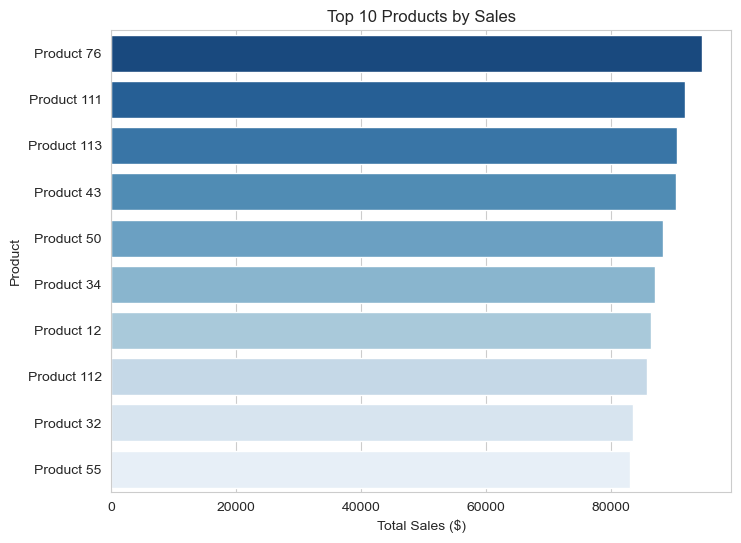

In [98]:
# Group data by product_name and get total sales, then take the top 10
top_products = merged.groupby('product_name')['sales'].sum().sort_values(ascending=False).head(10).reset_index()

# Create horizontal bar chart of top 10 products by sales
plt.figure(figsize=(8, 6))
sns.barplot(data=top_products, x='sales', y='product_name', palette='Blues_r')

plt.xlabel('Total Sales ($)')
plt.ylabel('Product')
plt.title('Top 10 Products by Sales')
plt.show()

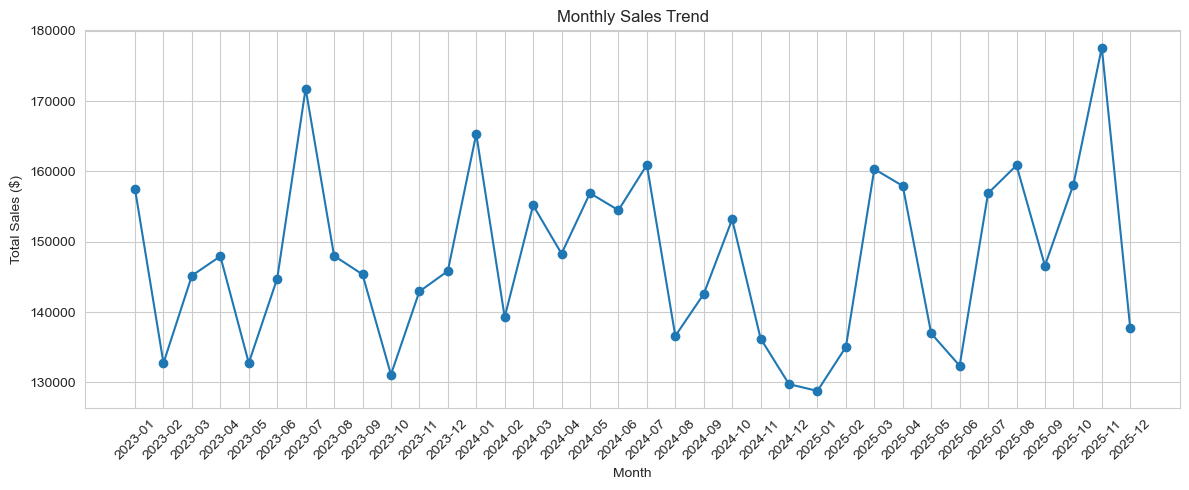

In [100]:
# Create a year-month column for grouping (e.g. '2023-01')
merged['order_month'] = merged['order_date'].dt.to_period('M')

# Group by month and sum sales
monthly_sales = merged.groupby('order_month')['sales'].sum().reset_index()
monthly_sales['order_month'] = monthly_sales['order_month'].astype(str)  # convert back to string for plotting

# Create line chart of sales over time
plt.figure(figsize=(12, 5))
plt.plot(monthly_sales['order_month'], monthly_sales['sales'], marker='o')

plt.xlabel('Month')
plt.ylabel('Total Sales ($)')
plt.title('Monthly Sales Trend')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()